# Multi-Region Sensor Placement Tutorial

In practical sensor placement applications, it is often impossible to install sensors in certain regions, for example, within solid domains. This tutorial demonstrates how to use `pyforce` for multi-region cases through the `ReadFromOFMultiRegion` class to import multi-region mesh, field and to restrict sensor placement region.

The tutorial applies the Empirical Interpolation Method (EIM), Generalized Empirical Interpolation Method (GEIM), and Parameterized Background Data–Weak (PBDW) approaches, following the methodology introduced in the tutorial “03_sensor_placement”.
The test case considered here is a Pressurized Water Reactor (PWR) pin cell consisting of three regions: Fuel, Cladding and Coolant.

By completing this tutorial, you will learn:

- How to read both region-based data and full-model data, including importing field "flux0", "prec0" (non-zero value in the 'FUEL' region, and uniform zeros in both "CLAD" and "COOL" regions); field "U" (only values in the 'COOL' region).
- How to restrict sensor placement to specific regions using the EIM, GEIM, and SGreedy algorithms for the flux field.

**Data and Geometry**: The dataset is based on the geometric model (https://doi.org/10.1016/j.nucengdes.2023.112164) with the axial length reduced to 0.5 m for computational convenience.

## Importing mesh using ReadFromOFMultiRegion

First, let's import the ReadFromOFMultiRegion class from the pyforce module and instantiate it. Here, we directly read from processor* decomposed files, switching `decomposed_case` to 'True'. This way can avoid "reconstructPar" operation in OpenFOAM, saving cost.

In [1]:
from pyforce.tools.write_read import ReadFromOFMultiRegion

# Class instantiation
path_case = '../Datasets/FuelPin-MultiRegion/'
of = ReadFromOFMultiRegion(path_case, decomposed_case=True, skip_zero_time=True)

Case Type decomposed


### Importing mesh and visualizing

This part aims to import the mesh for both the full model and selected subregions, and visualizes them using the Plotter class provided by pyvista.

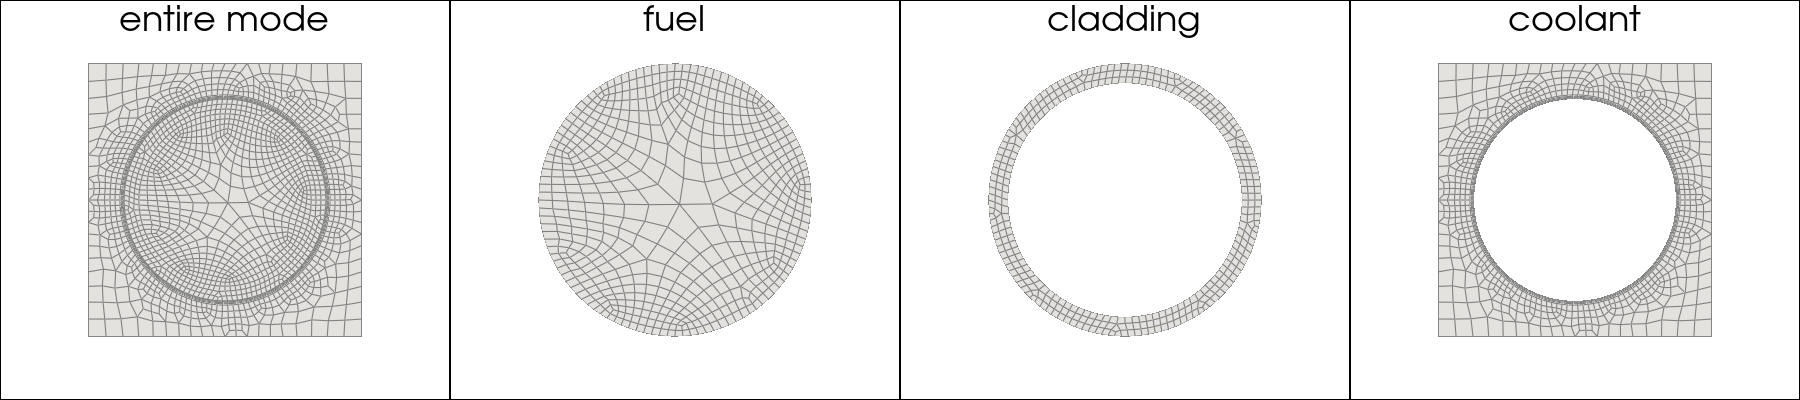

In [ ]:
import pyvista as pv

grid = of.mesh(decomposed_mode=False)
fuel_grid = of._region_mesh('FUEL')
clad_grid = of._region_mesh('CLAD')
cool_grid = of._region_mesh('COOL')

# print mesh, either by plot function (3D), or pyvista class
figs = 4
figs_title = ['entire mode','fuel','cladding','coolant']
pl = pv.Plotter(shape = (1,figs),window_size=(1800, 400))
for i,mesh in enumerate([grid,fuel_grid,clad_grid,cool_grid]):
    slice_z = mesh.slice(normal='z', origin=grid.center)
    pl.subplot(0, i)
    pl.add_mesh(slice_z, show_edges=True, color='white', opacity=0.5)
    pl.view_xy()
    pl.add_text(
        figs_title[i],
        position="upper_edge",
        font_size=14,
        color="black"
    )
pl.show(jupyter_backend='static')

## Import snaphots 

In this section, we can choose to import a field for a specific region at a given time, or import the field for all regions. It is important to note that some fields are only meaningful in certain regions. For example, the velocity field exists only in fluid regions. The `ReadFromOFMultiRegion` class provides the function `_get_valid_regions_for_field` to determine the valid regions associated with a given field. Here, we test this functionality using the flux0 field.

To import a specific field, the available import_mode includes: 
- 'pyvista'
- 'fluidfoam' 
- 'foamlib'

For multi-region case, three methods currently only support to importing cell data. After testing, we found that for multi-region cases, the efficiency for three modes are as follows: 'foamlib' > 'fluidfoam' > 'pyvista' (not recommended for multi-region cases). 

### Fast neutron flux field "flux0"

The class is embedded with the function `import_field` to import the field for specific region(s) or all regions. 

It is possible to extract the valid regions using `_get_valid_regions_for_field` function.

In [3]:
field = 'flux0' # Fast neutron flux

# check the valid region for the field
Valid_flux0_region = of._get_valid_regions_for_field(field)
print("The valid region for flux0: ", Valid_flux0_region)

# import field for all regions
allRegions_snap, times = of.import_field(field, import_mode='foamlib')

# import field for specific region
clad_snap, _ = of.import_field(field, regions_to_import='CLAD', import_mode='foamlib')
cool_snap, _ = of.import_field(field, regions_to_import='COOL', import_mode='foamlib')
fuel_snap, _ = of.import_field(field, regions_to_import='FUEL', import_mode='foamlib')


The valid region for flux0:  ['CLAD', 'COOL', 'FUEL']
Importing flux0 - foamlib: 3.000 / 3.00 - 3.633532 s/it
Importing flux0 - foamlib: 1.000 / 1.00 - 3.231550 s/it
Importing flux0 - foamlib: 1.000 / 1.00 - 3.859643 s/it
Importing flux0 - foamlib: 1.000 / 1.00 - 2.981186 s/it


Here, we define a function to extract a slice at the mid-plane.

In [4]:
import numpy as np
import pyvista as pv

def get_slice_data(grid: pv.UnstructuredGrid, snap, origin=None):
    if origin is None:
        origin = grid.center

    g = grid.copy()
    g.cell_data["fun"] = snap

    g = g.clean()

    g = g.cell_data_to_point_data()
    slc = g.slice(normal="z", origin=origin)

    data = slc.point_data["fun"]
    return slc.points, data, np.min(data), np.max(data)

To verify that the field has been successfully imported, this section visualizes the fast neutron flux (flux0) on the mid-plane slice using matplotlib.pyplot. is important to note that, compared to the Plotter class provided by pyvista, matplotlib.pyplot performs automatic interpolation. Therefore, masks are applied to restrict the visualization to the target region. It is recommended to use Plotter for complex geometries, while matplotlib.pyplot is suitable for simpler cases.

/Users/sriva/miniconda3/envs/ml/lib/python3.10/site-packages/matplotlib/tri/_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


Text(0.5, 0.98, 'Flux0 field at t=2.00 s')

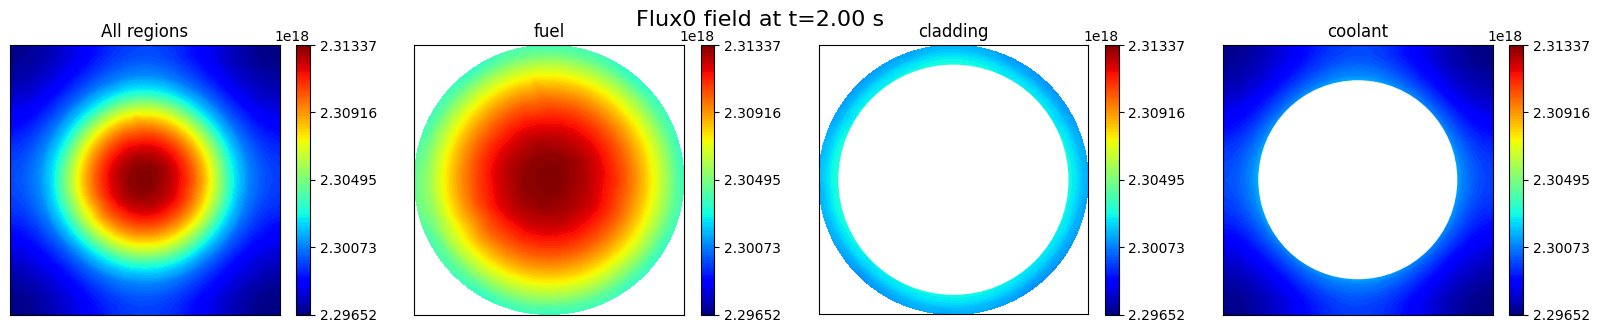

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# initialize
nrows = 1
ncols = 4
tt = len(times)-2 # the last second snapshot
t = times[tt]
figs_title = ['All regions','fuel','cladding','coolant']
fig, axs = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))

# get slice data
allRegion_sliced_points, allRegion_sliced_data, allRegion_slice_min, allRegion_slice_max = get_slice_data(grid, allRegions_snap[tt])
fuel_sliced_points, fuel_sliced_data, fuel_slice_min, fuel_slice_max = get_slice_data(fuel_grid, fuel_snap[tt])
clad_sliced_points, clad_sliced_data, clad_slice_min, clad_slice_max = get_slice_data(clad_grid, clad_snap[tt])
cool_sliced_points, cool_sliced_data, cool_slice_min, cool_slice_max = get_slice_data(cool_grid, cool_snap[tt])

c = axs[0].tricontourf(allRegion_sliced_points[:, 0], allRegion_sliced_points[:, 1], allRegion_sliced_data, levels=np.linspace(allRegion_slice_min, allRegion_slice_max, 100), cmap='jet')
c = axs[1].tricontourf(fuel_sliced_points[:, 0], fuel_sliced_points[:, 1], fuel_sliced_data, levels=np.linspace(allRegion_slice_min, allRegion_slice_max, 100), cmap='jet')
c = axs[2].tricontourf(clad_sliced_points[:, 0], clad_sliced_points[:, 1], clad_sliced_data, levels=np.linspace(allRegion_slice_min, allRegion_slice_max, 100), cmap='jet')
c = axs[3].tricontourf(cool_sliced_points[:, 0], cool_sliced_points[:, 1], cool_sliced_data, levels=np.linspace(allRegion_slice_min, allRegion_slice_max, 100), cmap='jet')

# circles for mask
c1 = Circle((0.0, 0.0), radius=0.0041, edgecolor='None', facecolor='white', linewidth=1) # fuel radius
c2 = Circle((0.0, 0.0), radius=0.0048, edgecolor='None', facecolor='white', linewidth=1) # clad radius

axs[2].add_patch(c1) # mask for cladding 
axs[3].add_patch(c2) # mask for coolant

for i in range(nrows*ncols):
    axs[i].set_title(f'{figs_title[i]}')
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_aspect('equal', 'box')
    fig.colorbar(c, ax=axs[i], ticks = np.linspace(allRegion_slice_min, allRegion_slice_max, 5))

fig.suptitle(f'Flux0 field at t={t:.2f} s', fontsize=16)

### First Group of Precursors "prec0"

Field 'prec0' only exists in the "FUEL" region, since it is related to fission products only, whereas it is a uniform value of 0 in the "CLAD" and "COOL" regions. 

*In order to ensure that the dimensions are consistent across the entire domain, the `import_field` function will assign the uniform value to all cells in these two regions.*

In [6]:
Valid_prec0_region = of._get_valid_regions_for_field('prec0')
print("The valid region for prec0: ", Valid_prec0_region)

prec0_snap, _ = of.import_field('prec0', import_mode='foamlib')

prec0_fuel_snap = of.import_field('prec0', regions_to_import='FUEL', import_mode='foamlib')[0]

The valid region for prec0:  ['CLAD', 'COOL', 'FUEL']
Importing prec0 - foamlib: 3.000 / 3.00 - 2.399710 s/it
Importing prec0 - foamlib: 1.000 / 1.00 - 1.983810 s/it


Let us plot the field "prec0" on the mid-plane slice to verify the successful import. 

Text(0.5, 0.98, 'prec0 field at t=2.00 s')

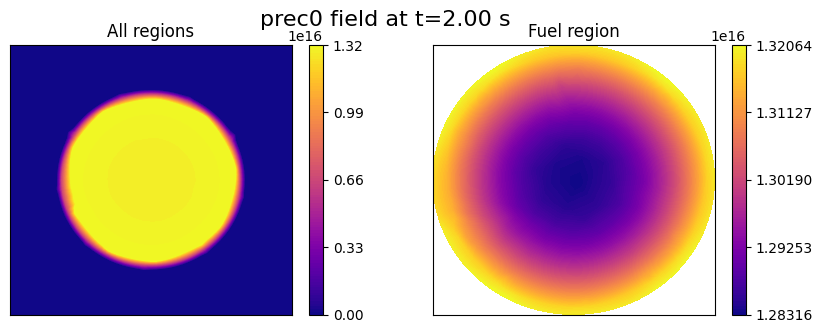

In [7]:
# visualize
nrows = 1
ncols = 2

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))

# get slice data
allRegion_sliced_points_prec0, allRegion_sliced_data_prec0, allRegion_slice_min_prec0, allRegion_slice_max_prec0 = get_slice_data(grid, prec0_snap[tt])

fuel_sliced_points, fuel_sliced_data, fuel_slice_min, fuel_slice_max = get_slice_data(fuel_grid, prec0_fuel_snap[tt])

c1 = axs[0].tricontourf(allRegion_sliced_points_prec0[:, 0], allRegion_sliced_points_prec0[:, 1], allRegion_sliced_data_prec0, levels=np.linspace(allRegion_slice_min_prec0, allRegion_slice_max_prec0, 100), cmap='plasma')
fig.colorbar(c1, ax=axs[0], ticks = np.linspace(allRegion_slice_min_prec0, allRegion_slice_max_prec0, 5))

c2 = axs[1].tricontourf(fuel_sliced_points[:, 0], fuel_sliced_points[:, 1], fuel_sliced_data, levels=np.linspace(fuel_slice_min, fuel_slice_max, 100), cmap='plasma')
fig.colorbar(c2, ax=axs[1], ticks = np.linspace(fuel_slice_min, fuel_slice_max, 5))

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

axs[0].set_title('All regions')
axs[1].set_title('Fuel region')

fig.suptitle(f'prec0 field at t={t:.2f} s', fontsize=16)

### Velocity "U"

Field "U" only exists in the "COOL" region, thus the method `import_field` will import only the velocity data in the "COOL" region, discarding the other regions, where no file "U" exists.

In [8]:
Valid_U_region = of._get_valid_regions_for_field('U')
print("The valid region for U: ", Valid_U_region)

U_snap, times = of.import_field('U', import_mode='foamlib')

The valid region for U:  ['COOL']
Importing U - foamlib: 1.000 / 1.00 - 6.373866 s/it


Recalling that vectors are imported as flattened arrays, we can reshape the velocity data to obtain the velocity components in the x, y, and z directions and visualize the velocity magnitude on the mid-plane slice.

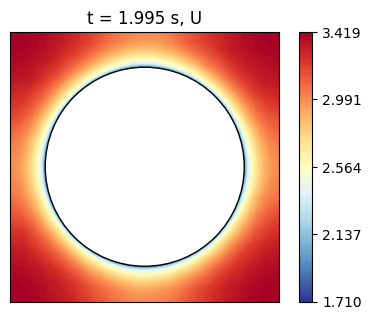

In [9]:
nrows = 1
ncols = 1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))

u_mag = np.linalg.norm(U_snap[tt].reshape(-1, 3), axis=1) # reshape the flattened array to (N, 3) and compute the magnitude

# get slice data
allRegion_sliced_points_U, allRegion_sliced_data_U, allRegion_slice_min_U, allRegion_slice_max_U = get_slice_data(cool_grid, u_mag)

c = axs.tricontourf(allRegion_sliced_points_U[:, 0], allRegion_sliced_points_U[:, 1], allRegion_sliced_data_U, levels=np.linspace(allRegion_slice_min_U, allRegion_slice_max_U, 100), cmap='RdYlBu_r')

c0 = Circle((0.0, 0.0), radius=0.0048, edgecolor='black', facecolor='white', linewidth=1) # clad radius
axs.add_patch(c0) # mask for coolant

axs.set_title(f't = {t} s, U')
axs.set_xticks([])
axs.set_yticks([])
axs.set_aspect('equal', 'box')
fig.colorbar(c, ax=axs, ticks = np.linspace(allRegion_slice_min_U, allRegion_slice_max_U, 5))

## Define Candidate Points for Sensor Placement

This section explains how to use `pyforce` functionalities to extract candidate points for sensor placement, using regional grids. The functions can be generally applied to any grids (not limited to OpenFOAM meshes) as long as the grid is imported as a `pyvista` object.

As well known in the literature, sensors in nuclear reactors can be placed only in specific regions, thus the candidate points for sensor placement should be selected from the valid region(s). Let us limit ourselves to have sensors in the "cool" region, and extract the candidate points from the "COOL" grid. The function `get_candidate_regions_points` can be used to extract the candidate points from the "COOL" grid.

In practice, by looking at the picture below, we want to extract from the full grid the points that are located in the "COOL" region, which is represented by the red points. The function `get_candidate_regions_points` can be used to extract these candidate points for sensor placement, especially if indices are needed.

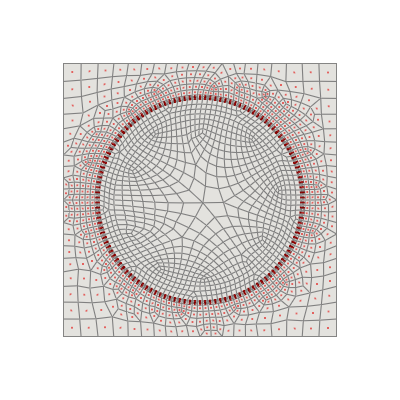

In [10]:
pl = pv.Plotter(window_size=(400, 400))

pl.add_mesh(grid.slice(normal='z', origin=grid.center), show_edges=True, color='white', opacity=0.5)
pl.add_points(cool_grid.slice(normal='z', origin=grid.center).cell_centers().points, color='red', point_size=2)
pl.view_xy()

pl.show(jupyter_backend='static')

Let us extract the candidate points.

In [11]:
from pyforce.tools.write_read import get_candidate_regions_points

candidate_points, candidate_idx = get_candidate_regions_points(grid, cool_grid)

Let us visualize the candidate points on the mid-plane slice to verify that they are correctly extracted from the "COOL" region.

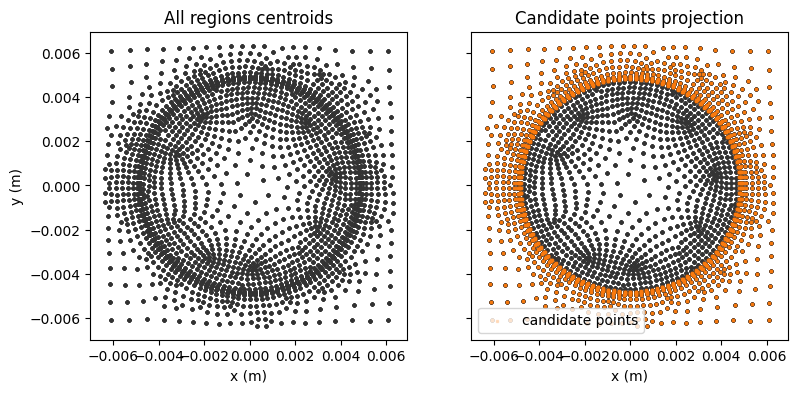

In [12]:
points = grid.cell_centers().points
nodes_cool = points[candidate_idx]

fig, axs = plt.subplots(1,2, figsize=(4.5*2,4), sharex=True, sharey=True)

figs_title = ['All regions centroids', 'Candidate points projection']
axs[0].set_ylabel('y (m)')
for i,ax in enumerate(axs):
    ax.set_xlabel('x (m)')
    axs[i].set_title(figs_title[i])
mark_size = 3

axs[0].scatter([p[0] for p in points], [p[1] for p in points], color="#333333", s=mark_size)

axs[1].scatter([p[0] for p in points], [p[1] for p in points], color="#333333", s=mark_size)
axs[1].scatter(nodes_cool[:,0], nodes_cool[:,1], color="#ff7f0e", s=mark_size, label='candidate points', marker='s', alpha=0.2)
axs[1].legend()

It can be also useful to locate a list of candidate points on the full grid to find the closest cell centroids, which can be used for sensor placement. 

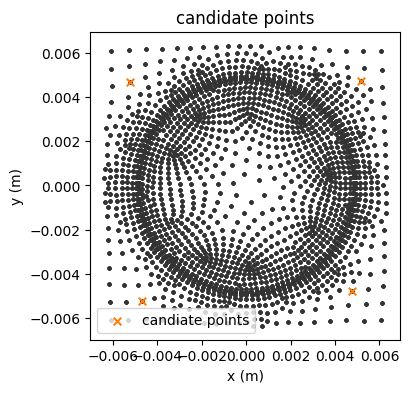

In [13]:
candidate_probes = []
candidate_probes.append([-0.005,-0.005,0.1])
candidate_probes.append([0.005,-0.005,0.1])
candidate_probes.append([-0.005,0.005,0.1])
candidate_probes.append([0.005,0.005,0.1])

from pyforce.tools.write_read import get_candidate_probes

candidate_fixed_points, candidate_fixed_idx = get_candidate_probes(grid, cool_grid, candidate_probes)
nodes_fixed_point = points[candidate_fixed_idx]

fig, ax = plt.subplots(figsize=(4, 4))

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('candidate points')
mark_size = 3

ax.scatter([p[0] for p in points], [p[1] for p in points], color="#333333", s=mark_size)
ax.scatter(nodes_fixed_point[:,0], nodes_fixed_point[:,1], color="#ff7f0e", s=30, marker='x', label='candiate points')
ax.legend()


For some applications, it is useful to place sensors along channels (in the $z$-direction only at the moment).

In [14]:
from pyforce.tools.write_read import get_candidate_channel_all_points

candidate_1 = []
candidate_1.append([-0.005,-0.005])
candidate_points_1, candidate_idx_1 = get_candidate_channel_all_points(grid, cool_grid, candidate_1, tol = 3.5e-4)

candidate_2 = []
candidate_2.append([-0.005,0.005])
candidate_points_2, candidate_idx_2 = get_candidate_channel_all_points(grid, cool_grid, candidate_2, tol = 3.5e-4)

candidate_3 = []
candidate_3.append([0.005,-0.005])
candidate_points_3, candidate_idx_3 = get_candidate_channel_all_points(grid, cool_grid, candidate_3, tol = 3.5e-4)

candidate_4 = []
candidate_4.append([0.005,0.005])
candidate_points_4, candidate_idx_4 = get_candidate_channel_all_points(grid, cool_grid, candidate_4, tol = 3e-4)

candidate_channel_idx = np.concatenate((candidate_idx_1,candidate_idx_2,candidate_idx_3,candidate_idx_4))
candidate_channel_points = grid.cell_centers().points[candidate_channel_idx]

Visualise fixed channels for sensor placemnet

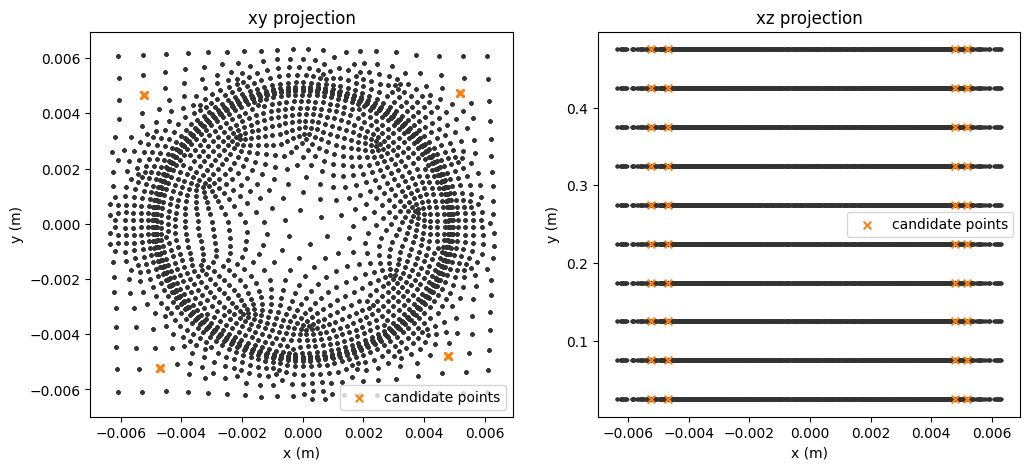

In [15]:
fig, axs = plt.subplots(1,2, figsize=(6*2,5))

figs_title = ['xy projection', 'xz projection']
for i,ax in enumerate(axs):
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    axs[i].set_title(figs_title[i])
mark_size = 3

axs[0].scatter(points[:,0], points[:,1], color="#333333", s=mark_size)
axs[0].scatter(candidate_channel_points[:,0], candidate_channel_points[:,1], color="#ff7f0e", s=30, marker='x',label='candidate points')
axs[0].legend()

axs[1].scatter(points[:,0],points[:,2], color="#333333", s=mark_size)
axs[1].scatter(candidate_channel_points[:,0], candidate_channel_points[:,2], color="#ff7f0e", s=30, marker='x',label='candidate points')
axs[1].legend()

## Physics-based Sensor Placement

In this last section, we apply the EIM, GEIM and PBDW approaches for sensor placement, following the methodology introduced in the tutorial “03_sensor_placement”. The only difference is that here we restrict the sensor placement to the "COOL" region by using the candidate points extracted from the "COOL" grid.

Let us split the flux snapshots into training and testing sets first and scale with respect to the initial condition (IC).

In [16]:
from pyforce.tools.functions_list import train_test_split

times = times
snaps = allRegions_snap # these are the snaps for the flux0 field

train_params, test_params, train_dataset, test_dataset = train_test_split(times, snaps, test_size=0.2, random_state=42)

# Sorting the dataset with respect to the time parameter - plotting purposes
_argsort = np.argsort(train_params)
train_params = np.array(train_params)[_argsort]
train_dataset.sort(_argsort)

_argsort = np.argsort(test_params)
test_params = np.array(test_params)[_argsort]
test_dataset.sort(_argsort)

from pyforce.tools.scalers import MinMaxScaler
scaler = MinMaxScaler(wrt_ic=True)
scaler.fit(train_dataset)
train_dataset = scaler.transform(train_dataset)
test_dataset = scaler.transform(test_dataset)

### Offline Stage

After obtaining the candidate indices and points, this section performs the offline-stage training, following the procedures introduced in the tutorial “03_sensor_placement”. The placement constraints are specified via the _xm_idx argument for EIM and the xm_list argument for GEIM. These parameters are restricted to the coolant region.

In [17]:
# initialize
#=======================
Mmax = 10
gdim = 3
s = 1e-3
#======================

# EIM
from pyforce.offline.eim import EIM

eim_offline = EIM(grid, gdim=gdim, varname=field)
train_eim_coeffs = eim_offline.fit(train_snaps=train_dataset, Mmax = Mmax, 
                                   _xm_idx = candidate_idx, 
                                   verbose=True)[1]
# GEIM
from pyforce.offline.geim import GEIM
geim_offline = GEIM(grid, gdim=gdim, varname=field, sensors_type='Gaussian')
sens_params = {
    's': s, # spread of the Gaussian kernels - hyperparameter to be tuned according to the physical system
    'xm_list': candidate_points # downsampled candidate points for computational efficiency
}
train_geim_coeff = geim_offline.fit(train_snaps=train_dataset, Mmax = Mmax, 
                                    sensor_params=sens_params, verbose=True)[2]

  Iteration 010 | Abs Err (Linfty): 3.50e-04 - EIM done
Creating Gaussian Sensor Library: 100.000 / 100.00% - 0.000289 s/it


The SGreedy algorithm is a greedy method generalized to any reduced basis and any linear functional used as a sensor. In particular, SGreedy requires a reduced basis spanning an associated reduced space as input. This basis can, for example, be obtained via a POD of the training snapshots. Sensors are then selected to maximize the information provided, spanning an update space of dimension Mmax.

To this end, we perform a randomized SVD of the training snapshots.

SVD of flux0 snapshots calculated in 1.150304 seconds (cpu).


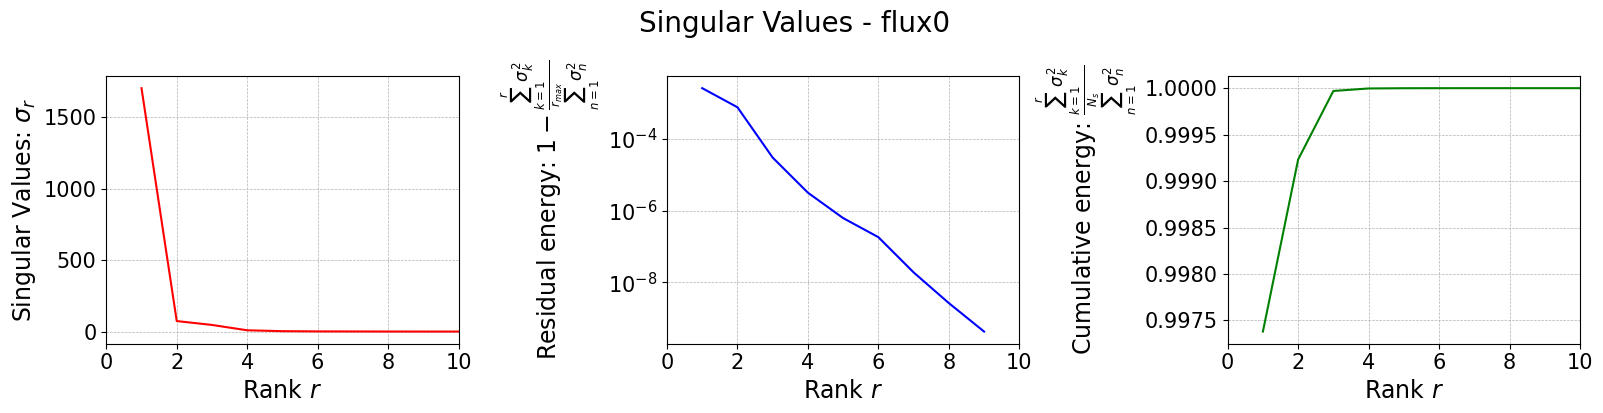

In [18]:
from pyforce.offline.pod import rSVD

svd_offline = rSVD(grid, gdim=gdim, varname=field)
svd_offline.fit(train_snaps=train_dataset, rank=Mmax, verbose=True)

svd_fig = svd_offline.plot_sing_vals()
axs = svd_fig.get_axes()
for ax in axs:
    ax.set_xlim(0,Mmax)

Once the basis is computed, we can use it to perform the SGreedy sensor placement. The initialization of the class is similar to the previous cases.

The training of the SGreedy algorithm, through the fit method, requires the basis functions spanning the reduced space (using only the first 5 modes), the maximum number of sensors to be placed, and the sensor parameters (similar to the GEIM case).

In [19]:
# PBDW
from pyforce.offline.sgreedy import SGREEDY
sgreedy_placement = SGREEDY(grid, gdim=gdim, varname=field)

sens_params = {
    's': s, # spread of the Gaussian kernels - hyperparameter to be tuned according to the physical system
    'xm_list': candidate_points, # downsampled candidate points for computational efficiency
}

rank_svd = 4

sgreedy_placement.fit(
    basis_functions= svd_offline.svd_modes[:rank_svd],
    Mmax = Mmax,
    sensor_params=sens_params
)

Creating Gaussian Sensor Library: 100.000 / 100.00% - 0.000281 s/it


### Visualize Sensor Placement

Once the basis is computed, it can be used to perform SGreedy sensor placement. The initialization of the class is similar to the previous cases.

Training the SGreedy algorithm via the fit method requires the basis functions spanning the reduced space (using only the first five modes), the maximum number of sensors to be placed, and the sensor parameters (similar to the GEIM case).

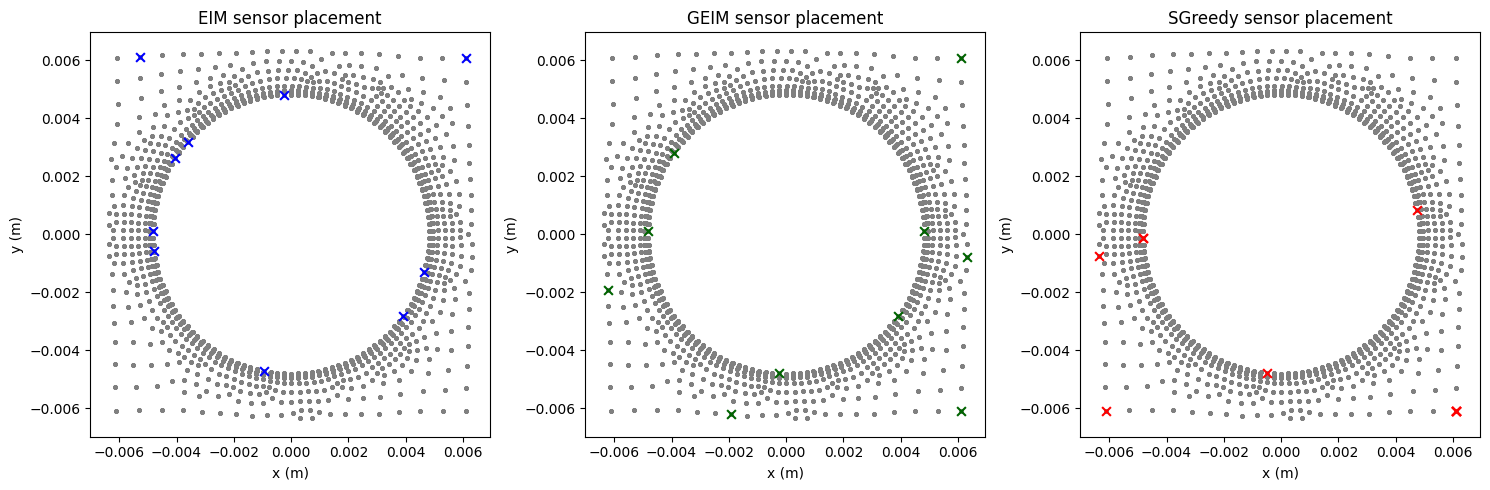

In [20]:
# compare the placement
fig, axs = plt.subplots(1,3, figsize=(15,5))
markersize = 40

for ax in axs:
    ax.scatter(cool_grid.cell_centers().points[:,0], cool_grid.cell_centers().points[:,1], marker='o', color='0.5', s=5); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

axs[0].scatter([p[0] for p in eim_offline.magic_points['points']], [p[1] for p in eim_offline.magic_points['points']], marker='x', color='b', s=markersize, label='EIM magic points')

axs[1].scatter([grid.cell_centers().points[geim_offline.magic_sensors.library(pp).argmax(), 0] for pp in range(len(geim_offline.magic_sensors))], [grid.cell_centers().points[geim_offline.magic_sensors.library(pp).argmax(), 1] for pp in range(len(geim_offline.magic_sensors))], marker='x', color='darkgreen', s=markersize, label='GEIM magic points')

axs[2].scatter([p[0] for p in sgreedy_placement.sensor_centers], [p[1] for p in sgreedy_placement.sensor_centers], marker='x', color='r', s=markersize, label='SGreedy sensors')

axs[0].set_title('EIM sensor placement'); axs[1].set_title('GEIM sensor placement'); axs[2].set_title('SGreedy sensor placement')

plt.tight_layout()

Furthermore, since our case involves a 3D geometry, this section visualizes the distribution of all sensors for the GEIM approach; the other two approaches are omitted to save space.

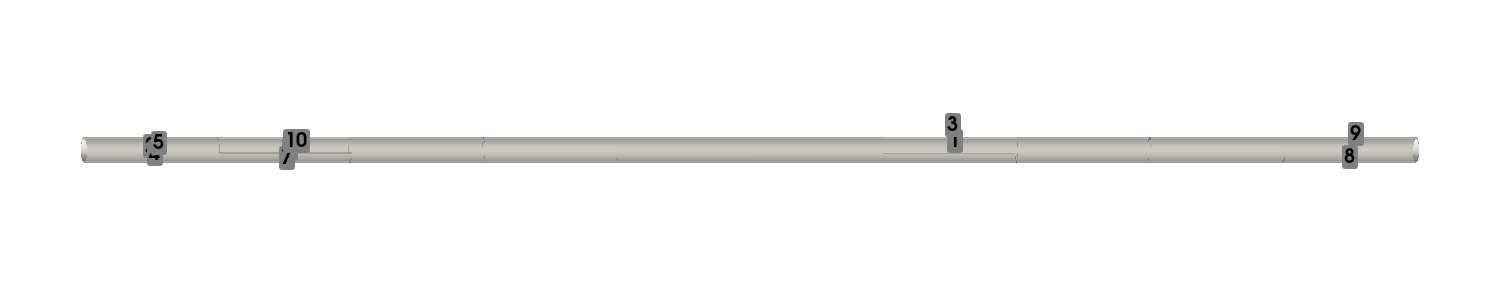

In [21]:
# sensor nodes
nodes = geim_offline.magic_sensors.nodes
max_idx = np.argmax(geim_offline.magic_sensors.library.return_matrix(), axis=0)[:Mmax]

pl = pv.Plotter(window_size=[1500, 300])
pl.add_mesh(of._region_mesh('CLAD').rotate_y(90), color='white', show_edges=False, opacity=0.5)

# add sensor scatter
for ii in range(len(max_idx)):
    idx = max_idx[ii]
    orig_p = nodes[idx]
    rotated_p = [orig_p[2], orig_p[1], -orig_p[0]]
    pl.add_mesh(
        pv.Sphere(radius=0.001, center=rotated_p),  # using sphere
        color='green'
    )
    pl.add_point_labels(
        points=rotated_p,           # Explicit (1, 3) array
        labels=[str(ii + 1)],       
        font_size=20,               # 80 might be huge depending on zoom
        text_color='black',
        always_visible=True,        
        point_size=0,
        render_points_as_spheres=False
    )

pl.view_xy()
pl.zoom_camera(4.5)

pl.show(jupyter_backend='static')

### Online Stage

In this section, we perform online-stage training using the EIM, GEIM, and PBDW approaches.

In [22]:
#Online stage
noise_std = 0.05*train_dataset.mean()

# EIM
from pyforce.online.eim import EIM as OnlineEIM

eim_online = OnlineEIM(grid, gdim=gdim, varname=field)
eim_online.set_basis(eim_offline.magic_functions)
eim_online.set_magic_points(eim_offline.magic_points)

# Assemble Tikhonov regularization matrix
eim_online.set_tikhonov_matrices(beta_coeffs=train_eim_coeffs)

# Prediction with EIM
test_eim_measures = eim_online.get_measurements(test_dataset, noise_std=noise_std)
eim_prediction = eim_online.estimate(test_eim_measures, regularization_params={'type': 'tikhonov', 'lambda': noise_std**2})

# GEIM
from pyforce.online.geim import GEIM as OnlineGEIM

geim_online = OnlineGEIM(grid, gdim=gdim, varname=field)
geim_online.set_basis(geim_offline.magic_functions)
geim_online.set_magic_sensors(geim_offline.magic_sensors.library)

# Assemble Tikhonov regularization matrix
geim_online.set_tikhonov_matrices(beta_coeffs=train_geim_coeff)

# Prediction with GEIM
test_geim_measures = geim_online.get_measurements(test_dataset, noise_std=noise_std)
geim_prediction = geim_online.estimate(test_geim_measures, regularization_params={'type': 'tikhonov', 'lambda': noise_std**2})

# PBDW
from pyforce.online.pbdw import PBDW
pbdw_online = PBDW(grid, gdim=gdim, varname=field)
pbdw_online.set_basis(svd_offline.svd_modes[:rank_svd])
pbdw_online.set_basis_sensors(sgreedy_placement.sensors.library)

pbdw_online.compute_matrices()
pbdw_measures = pbdw_online.get_measurements(test_dataset, noise_std=noise_std)
pbdw_prediction = pbdw_online.estimate(pbdw_measures, xi=10)

We compare the results obtained using the three approaches: EIM, GEIM, and PBDW.

Computing errors: 80.000 / 80.00 - 0.000113 s/it


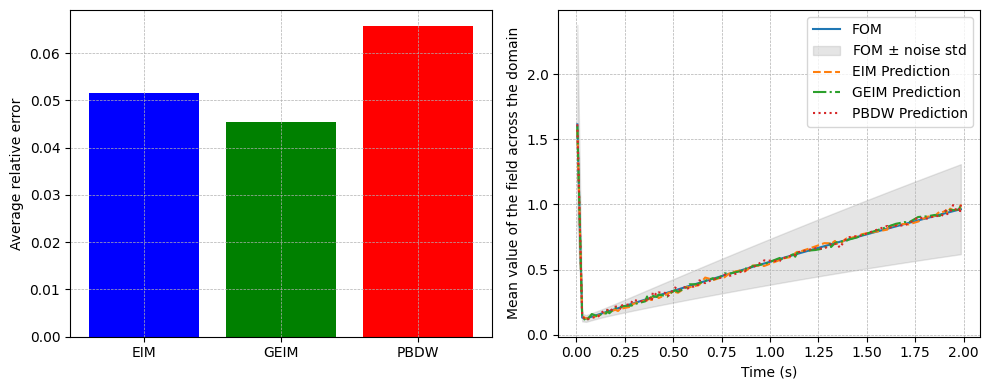

In [25]:
# Comparison of average relative errors
from pyforce.tools.backends import IntegralCalculator, LoopProgress
errors = {
    'EIM': [],
    'GEIM': [],
    'PBDW': []
}

calculator = IntegralCalculator(grid, gdim=gdim)
bar = LoopProgress(final=len(test_dataset), msg='Computing errors')

for mu, snap in enumerate(test_dataset):
    _snap_norm = calculator.L2_norm(snap)

    # EIM error
    errors['EIM'].append(
        calculator.L2_norm(snap - eim_prediction[mu]) / _snap_norm
    )

    # GEIM error
    errors['GEIM'].append(
        calculator.L2_norm(snap - geim_prediction[mu]) / _snap_norm
    )

    # PBDW error
    errors['PBDW'].append(
        calculator.L2_norm(snap - pbdw_prediction[mu]) / _snap_norm
    )

    bar.update(1)

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].bar(errors.keys(), [np.mean(errors[key]) for key in errors.keys()], 
        color=['blue', 'green', 'red'])
axs[0].set_ylabel('Average relative error')

axs[1].plot(test_params, test_dataset.mean(axis=0), label='FOM')
axs[1].fill_between(test_params, test_dataset.mean(axis=0) - test_dataset.std(axis=0), test_dataset.mean(axis=0) + test_dataset.std(axis=0), color='gray', alpha=0.2, label=r'FOM $\pm$ noise std')
axs[1].plot(test_params, eim_prediction.mean(axis=0), '--', label='EIM Prediction')
axs[1].plot(test_params, geim_prediction.mean(axis=0), '-.', label='GEIM Prediction')
axs[1].plot(test_params, pbdw_prediction.mean(axis=0), ':', label='PBDW Prediction')
axs[1].set_xlabel('Time (s)')
axs[1].legend()
axs[1].set_ylabel('Mean value of the field across the domain')

for ax in axs:
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()